<table align="center">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/c_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## [Lista de reproducción en YouTube para acompañar la lectura experimental de este capítulo](https://www.youtube.com/watch?v=FRqaBqy3prU&list=PLbk60veMSVKv7dAGRFIBwUf34TFDL0FdW)

# Capítulo 4
## ¿Qué significa entrenar un modelo? 
Aurelien Gerón

Hemos tratado 
* los **modelos de Machine Learning** y 
* sus **algoritmos de entrenamiento** 

en su mayoría como cajas negras.

Es mucho todo lo que puede hacer sin saber nada sobre lo que hay debajo del capó:  

* optimizar un **sistema de regresión**,   
* mejorar un **clasificador de imágenes de dígitos** e incluso 
* construir un clasificador de spam desde cero,   

todo esto sin saber cómo funcionan realmente.

De hecho, en muchas situaciones no es necesario conocer los detalles de implementación.

Sin embargo, tener una buena comprensión de cómo funcionan las cosas puede ayudarlo a:

* encontrar rápidamente el **modelo** apropiado, 
* el **algoritmo de entrenamiento** adecuado para usar y 
* un buen **conjunto de hiperparámetros** para su tarea. 

Comprender qué hay debajo del capó también lo ayudará a 
* depurar problemas y 
* realizar análisis de errores de manera más eficiente.

la mayoría de los temas discutidos en este capítulo serán esenciales para 

* comprender, 
* construir y 
* entrenar redes neuronales 

(discutidos en la Parte II de este libro).

* Habrá bastantes ecuaciones matemáticas en este capítulo, 
* usando nociones básicas de álgebra lineal y cálculo.

Para comprender estas ecuaciones, necesitarás saber:  

* qué son los vectores y las matrices; 
* cómo transponerlos, multiplicarlos e invertirlos; y 
* qué son las derivadas parciales.

Si no está familiarizado con estos conceptos, consulte los tutoriales introductorios de cálculo y álgebra lineal disponibles como cuadernos de Jupyter en el material complementario en línea: https://github.com/ageron/handson-ml3

Para aquellos que son realmente alérgicos a las matemáticas, aún deben leer este capítulo 
* y simplemente omitir las ecuaciones; 
* con suerte, el texto será suficiente para ayudarlo a comprender la mayoría de los conceptos.

# Linear Regression  

En el Capítulo 1 analizamos un modelo de regresión simple de calidad de vida:

## Ejemplo de Entrenamiento y ejecución de un modelo lineal con Scikit-Learn

In [2]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    '''
    esta función prepara estadísticas del pais
    '''
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", \
                              values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", \
                               'Life satisfaction']].iloc[keep_indices]

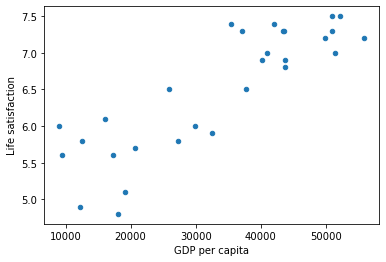

[[5.96242338]]


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model
# Load the data and 
oecd_bli = pd.read_csv("oecd_bli_2015.csv", thousands=',')
# thousand significa miles 
gdp_per_capita = pd.read_csv("gdp_per_capita.csv", thousands=',', delimiter='\t', encoding='latin1', na_values="n/a")
# Prepare the data
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]
# Visualize the data
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()
# Select a linear model
model = sklearn.linear_model.LinearRegression()
# Train the model
model.fit(X, y)
# Make a prediction for Cyprus 
X_new = [[22587]] # Cyprus's GDP per capita
print(model.predict(X_new)) # outputs [[ 5.96242338]]

# ¿Cómo funciona un modelo lineal?
* un modelo lineal hace una predicción simplemente calculando una **suma ponderada** de los atributos de entrada, 
* más una constante llamada **término de sesgo** (también llamado **término de intersección**)

Equation 4-1. Modelo predictivo de regresión lineal

$$ \hat{y} = \theta_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n} $$

$$ \hat{y} = \theta_{0}(1) + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n} $$

$$ \hat{y} = \mathbf{\theta} \cdot \mathbf{x}_{b}, \ \ \ \ \ \ \ \mathbf{x}_{b} = \begin{pmatrix} 1 \\ x_{1} \\ \vdots \\ x_{n} \end{pmatrix} $$  


$\hat{y}$ es el valor predicho.

$n$ es el número de características o atributos.

$x_{i}$ es el valor del $i$ - ésimo atributo. () Geron utiliza subíndice para las columnas de la matriz de datos `X`. 

$\theta_{j}$ es el $j$ - ésimo parámetro del modelo 
(incluido el término de sesgo $\theta_{0}$ y los pesos de los atributos $\theta_{1},\theta_{2},\ldots, \theta_{n}$).

Esto se puede escribir de manera mucho más concisa usando una forma vectorizada, como se muestra en la siguiente ecuación.

Predicción del modelo de regresión lineal (forma vectorizada)   


$$ \hat{y} = h_{\mathbf{\theta}}(\mathbf{x}_{b}) = \mathbf{\theta} \cdot \mathbf{x}_{b} $$

En esta ecuación:

* $\mathbf{\theta}$ es el vector de parámetros del modelo, que contiene el término de sesgo $\theta_{0}$ y el de los pesos de los atributos $\theta_{1}$ a $\theta_{n}$.

* $\mathbf{x}_{b}$ es el **vector de atributos** o de instancias, que contiene $x_{0}$ a $x_{n}$, con $x_{0}$ siempre igual a $1$.

* $\mathbf{\theta} \cdot \mathbf{x}_{b}$ es el producto escalar de los vectores $\mathbf{\theta}$ y $\mathbf{x}_{b}$, que por supuesto es igual a $\theta_{0}x_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + \cdots + \theta_{n}x_{n}.$

* $h_{\mathbf{\theta}}$ es la función hipótesis asociada a los parámetros $\mathbf{\theta}$ del modelo.

## NOTA

Si $\mathbf{\theta}$ y $\mathbf{x}_{b}$ son vectores de columna, entonces la predicción es 

$$ \hat{y} = \mathbf{\theta}^{T}\mathbf{x}_{b}, $$

donde $\mathbf{\theta}^{T}$ es la transposición de $\mathbf{\theta}$ (un vector de fila en lugar de un vector de columna) y   
$\mathbf{\theta}^{T}\mathbf{x}_{b}$ es el producto matricial las matrices $\theta^{T}$ y $\mathbf{x}_{b}$.

* este es el modelo de regresión lineal,   
* pero ¿cómo lo entrenamos?   

Recuerde que **entrenar un modelo** significa **establecer sus parámetros** para que el modelo se ajuste mejor al **conjunto de entrenamiento**.

Para este propósito, primero necesitamos una medida de qué tan bien (o mal) el modelo se ajusta a los **datos de entrenamiento**.

La medida de rendimiento más común de un modelo de regresión es **la raíz del error cuadrático medio (RMSE)**.

$$ RMSE(\theta) = \sqrt{\frac{1}{m}\sum_{j = 0}^{n} (\theta^{T} x^{j} - y^{j})^{2}} $$

donde $x^{j}$ es la $j$ - ésima fila o instancia de la matriz de datos `X_train`.  Es decir, para Geron, el super índice es para denotar las filas de la matriz. 

Por lo tanto, para entrenar un modelo de regresión lineal, necesitamos encontrar el valor de $\theta$ que minimice el RMSE.

* En la práctica, es más sencillo minimizar el error cuadrático medio (MSE) que el RMSE, 
* y conduce al mismo resultado (pues el valor que minimiza a la función, minimiza su raíz cuadrada). 

Se calcula el MSE de una hipótesis de regresión lineal $h$ en un conjunto de entrenamiento `X_train` usando la ecuación:  

$$ RMSE(\theta) = \sqrt{\frac{1}{m}\sum_{j = 0}^{n} (\theta^{T} x^{j} - y^{j})^{2}} $$


o la ecuación:

$$ MSE(X,h_{\theta}) = \frac{1}{m} \sum_{i = 1}^{n} (\mathbf{\theta}^{T}\mathbf{x}^{i} - y^{i} )^{2} $$

La única diferencia es que escribimos $h_{\mathbf{\theta}}$ en lugar de solo $h$ para dejar en claro que el modelo está parametrizado por el vector $\mathbf{\theta}$.

Para simplificar las notaciones, simplemente escribiremos $MSE(\mathbf{\theta})$ en lugar de $MSE(\mathbf{X}, h_{\mathbf{\theta}})$.

## La ecuación normal

Para encontrar el valor de $\mathbf{\theta}$ que minimiza la función de costo, existe una solución de forma cerrada, 
* en otras palabras, una ecuación matemática que da el resultado directamente.

Esto se llama **ecuación normal**

$$ \hat{\mathbf{\theta}} = (\mathbf{X}^{T}\mathbf{X})^{-1} \mathbf{X}^{T}\mathbf{y} $$

En esta ecuación:

* $\hat{\mathbf{\theta}}$ es el valor de $\mathbf{\theta}$ que minimiza la función de costo.

* $\mathbf{y}$ es el vector de valores objetivo que contiene $y^{(1)}$ a $y^{(m)}$.

# Generemos algunos datos de apariencia lineal para probar esta ecuación:

In [3]:
#importación de las librerías necesarias 

import numpy as np
import matplotlib.pyplot as plt  


In [4]:
# Fijamos un estado aleatorio para reproducibilidad
np.random.seed(48)
X = 2 * np.random.rand(100, 1) 
# Crea una matriz de orden 100 x 1 con valores aleatorios en el intervalo [0,2) 
# que distribuyen uniforme
y = 4 + 3 * X + np.random.randn(100, 1) # crea un vector de etiquetas

In [5]:
X[:5]

array([[0.03498054],
       [1.78314653],
       [0.56972233],
       [0.59795275],
       [1.58406852]])

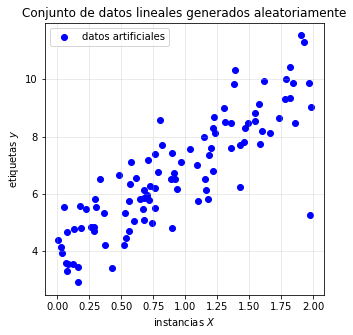

In [15]:
plt.figure(figsize=(5,5)) 
plt.scatter(X,y, color = 'blue', label = 'datos artificiales')    
plt.xlabel('instancias $X$')
plt.ylabel('etiquetas $y$')
plt.title('Conjunto de datos lineales generados aleatoriamente')
plt.legend()
plt.grid(alpha = 0.3) 
plt.savefig('dataset_lineal_aleatorio.jpg')
plt.show() 

Ahora calculemos $\hat{\mathbf{\theta}}$ usando la Ecuación Normal. 

Usaremos la función ``inv()`` del módulo de álgebra lineal de NumPy `` (np.linalg) `` para calcular la inversa de una matriz, y el método ``.dot()`` para la multiplicación de matrices:

In [12]:
import numpy as np 
# np.c_ concatena matrices 
X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best 

array([[4.0117793 ],
       [2.92444191]])

La función que usamos para generar los datos es 

$$ y = 4 + 3x + \text{Ruido Gausiano}.$$

Veamos qué encontró la ecuación:

In [8]:
theta_best

array([[4.0117793 ],
       [2.92444191]])

Habríamos esperado $\theta_{0} = 4$ y $\theta_{1}=3$ en lugar de $\theta_{0} = 4.01$ y $\theta_{1} = 2.924$.

Lo suficientemente cerca, pero el ruido hizo imposible recuperar los parámetros exactos de la función original.

Ahora podemos hacer predicciones usando $\hat{\mathbf{\theta}}$:

In [13]:
X_new = np.array([[0], [2]])               #  Un nuevo par de datos 
X_new_b = np.c_[np.ones((2, 1)), X_new]    # adiciona x0 = 1 a cada instancia
y_predict = X_new_b.dot(theta_best)    # efectúa el producto escalar 
y_predict # muestra las dos predicciones

array([[4.0117793 ],
       [9.86066312]])

Grafiquemos las predicciones de este modelo (Figura 4-2):

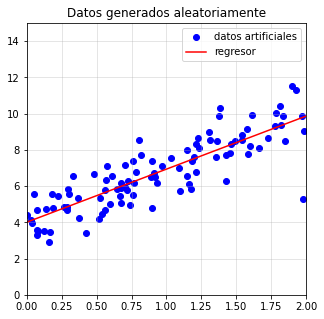

In [14]:
plt.figure(figsize = (5,5))
plt.title('Datos generados aleatoriamente')  
plt.scatter(X, y, color = 'blue', label = 'datos artificiales') 
plt.plot(X_new, y_predict, "r-", label = 'regresor')
plt.axis([0, 2, 0, 15])
plt.legend()
plt.grid(alpha = 0.4) 
plt.savefig('que_significa_entrenar_un_modelo.jpg')
plt.show()

# Realizar una regresión lineal con Scikit-Learn es simple:

In [7]:
from sklearn.linear_model import LinearRegression # tomar la clase 
lin_reg = LinearRegression()            # instanciamos la clase 
lin_reg.fit(X, y)                # constituyes la función predictora. 
lin_reg.intercept_, lin_reg.coef_

(array([4.0117793]), array([[2.92444191]]))

In [8]:
X_new = np.array([[0], [2]]) # datos nuevos 
lin_reg.predict(X_new) # predicciones para los dos datos anteriores

array([[4.0117793 ],
       [9.86066312]])

La clase ``LinearRegression`` se basa en la función ``scipy.linalg.lstsq()`` (el nombre significa "mínimos cuadrados"), a la que puede llamar directamente:

In [15]:
%%time 
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

CPU times: total: 46.9 ms
Wall time: 4.98 ms


array([[4.0117793 ],
       [2.92444191]])

Esta función calcula $\hat{\theta} = X^{+}y$ donde $X^{+}$ es la pseudoinversa de $X$ (específicamente, la inversa de Moore-Penrose).

$$ \hat{\theta}  = X^{+}y = (X^{T}X)^{-1}X^{T}y $$


Puede usar `np.linalg.pinv()` para calcular la pseudoinversa directamente:

In [16]:
np.linalg.pinv(X_b).dot(y)

array([[4.0117793 ],
       [2.92444191]])

La pseudoinversa en sí misma se calcula usando una técnica estándar de factorización de matrices llamada *Descomposición en valores singulares* (SVD) que puede descomponer la matriz del conjunto de entrenamiento $\mathbf{X}$ en la multiplicación de tres matrices $U\Sigma V^{T}$ (ver ``numpy.linalg.svd()``).

La pseudoinversa se calcula como $\mathbf{X}^{+} = \mathbf{V\Sigma}^{+}\mathbf{U}^{T}$.   

Para calcular la matriz $\Sigma^{+}$, 
* el algoritmo toma $\Sigma$ y 
* establece en cero todos los valores menores que un pequeño valor de umbral, 
* luego reemplaza todos los valores distintos de cero con su inverso y 
* finalmente transpone la matriz resultante.

* Este enfoque es más eficiente que calcular la Ecuación Normal, además maneja muy bien los casos extremos: 
* de hecho, la Ecuación Normal puede no funcionar si la matriz $\mathbf{X}^{T}\mathbf{X}$ no es invertible (es decir, singular), como  cuando $m < n$ o si tenemos atributos redundantes, pero la pseudoinversa siempre está definida.

Donde $n$ es el número de atributos y  
$m$ es el número de instancias. 

## Computational Complexity

La ecuación normal calcula la inversa de $\left(X\_b\right)^{T}X\_b$, que es una matriz $(n + 1) \times (n + 1)$ (donde $n$ es el número de atributos).

$$ \left( X\_b \right)^{T}_{(n+1) \times m} \left( X\_b\right)_{m\times (n+1)} $$

## Compejidad computacional para determinar la inversa de una matriz
La complejidad computacional de invertir una matriz de este tipo suele ser de $O(n^{2.4})$ a $O(n^{3})$, según la implementación. 

Donde $n$ es el número de atributos o columnas del vector $X$

En otras palabras, si duplica la cantidad $n$ de atributos, se multiplica **el tiempo de cálculo** en un rango aproximado de $2^{2.4} = 5.3$ a $2^{3} = 8$.

El enfoque SVD utilizado por la clase `LinearRegression` de Scikit-Learn es aproximadamente $O(n^{2})$. 

Si duplica la cantidad de atributos, multiplica el **tiempo de cálculo** por aproximadamente 4.

## Advertencia 

Tanto la ecuación normal como el enfoque SVD se vuelven muy lentos cuando la cantidad $n$ de atributos aumenta (por ejemplo a $100.000$).

En el lado positivo, ambos son lineales con respecto a la cantidad de instancias en el conjunto de entrenamiento (son $O(m)$), por lo que manejan grandes conjuntos de entrenamiento de manera eficiente, siempre que quepan en la memoria.  

Donde $m$ es el número de instancias o filas de la matriz de datos $X$.

Además, una vez que haya entrenado su modelo de regresión lineal (usando la ecuación normal o cualquier otro algoritmo),  
* las predicciones son muy rápidas: la complejidad computacional es lineal con respecto a la cantidad $m$ de instancias en las que desea hacer predicciones y la cantidad de atributos $n$.

En otras palabras, hacer **predicciones** sobre el doble de instancias $m$ (o el doble de atributos $n$) llevará aproximadamente el doble de tiempo.

Ahora veremos una forma muy diferente de entrenar un modelo de regresión lineal, que se adapta mejor a los casos en los que 

* hay una gran cantidad de atributos o 
* demasiadas instancias de entrenamiento para caber en la memoria.

## Gradient Descent  

Gradient Descent es un **algoritmo de optimización** genérico capaz de encontrar soluciones óptimas a una amplia gama de problemas.

La idea general de Gradient Descent es ajustar los parámetros **iterativamente** para minimizar una función de costo.

* Suponga que está perdido en las montañas en una densa niebla, y   
* solo puede sentir la pendiente del suelo debajo de sus pies.

Una buena estrategia para llegar rápidamente al fondo del valle es descender en dirección a la pendiente más pronunciada.

Esto es exactamente lo que hace Gradient Descent: 
* mide el gradiente local de la **función de error** con respecto al vector de parámetros $\theta$, y va en la dirección del gradiente descendente. 

Una vez que el gradiente es cero, ¡ha alcanzado un mínimo!

Concretamente, comienza inicializando $\theta$ con valores aleatorios (esto se llama **inicialización aleatoria**).

Luego lo mejora gradualmente, dando un pequeño paso a la vez, cada paso intentando disminuir la función de costo (por ejemplo, el MSE), hasta que el algoritmo converge a un mínimo.

<img src='https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_3.JPG?raw=true'>

* Un parámetro importante en Gradient Descent es el **tamaño de los pasos**,   

* determinado por el hiperparámetro de **tasa de aprendizaje**. 

Si la tasa de aprendizaje es demasiado pequeña, el algoritmo tendrá que pasar por muchas iteraciones para converger, lo que llevará mucho tiempo.

<img src='https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_4.JPG?raw=true'>

Por otro lado, si la tasa de aprendizaje es demasiado alta, es posible que saltes al otro lado del valle y termines en el otro lado, posiblemente incluso más alto de lo que estabas antes.

Esto podría hacer que el algoritmo diverja, con valores cada vez mayores, y no pueda encontrar una buena solución.

<img src='https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_5.JPG?raw=true'>

Por último, no todas las **funciones de costos** se ven como buenos cuencos (son convexas o concavas hacia arriba). 

Puede haber agujeros, crestas, mesetas y todo tipo de terrenos irregulares, haciendo dificil la convergencia al mínimo global. 

La figura 4-6 muestra los dos desafíos principales del Gradiente descendente.

<img src='https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_6.JPG?raw=true'> 

Si la inicialización aleatoria comienza el algoritmo por el lado izquierdo, entonces convergen a un mínimo local, que no es tan bueno como el mínimo global. 

Si se comienza a la derecha, entonces tomará mucho tiempo cruzar la meseta. 

Y si si se detiene demasiado pronto, nunca alcanzará el mínimo global.

Afortunadamente, **la función de costo MSE** para un modelo de regresión lineal resulta ser una **función convexa**, lo que significa que si selecciona dos puntos en la curva, el segmento de línea que los une nunca cruza la curva.

Esto implica que no hay mínimos locales, solo un mínimo global.

También es una función continua con una pendiente que nunca cambia abruptamente.

Estos dos hechos tienen una gran consecuencia:
* Se garantiza que Gradient Descent se acerque arbitrariamente al mínimo global (si espera lo suficiente y si la tasa de aprendizaje no es demasiado alta).

De hecho, la **función de costo** tiene forma de cuenco o recipiente, pero puede ser un cuenco alargado si los atributos tienen escalas muy diferentes.

* La figura 4-7 muestra el descenso de gradiente en un conjunto de entrenamiento donde los atributos 1 y 2 tienen la misma escala (a la izquierda)   
* y en un conjunto de entrenamiento donde el atributo 1 tiene valores mucho más pequeños que el atributo 2 (a la derecha).

<img src='https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_7.JPG?raw=true'> 

* Como puedes ver, a la izquierda el algoritmo de Descenso de Gradiente va directo hacia el mínimo, alcanzándolo rápidamente,  
* mientras que a la derecha primero va en una dirección casi ortogonal a la dirección del mínimo global, y termina con una marcha larga por un valle casi plano.

Eventualmente alcanzará el mínimo, pero tomará mucho tiempo.

## Advertencia

Al usar Gradient Descent, debe asegurarse de que todas los atributos tengan una escala similar

* por ejemplo usando la clase `StandardScaler` de Scikit-Learn o,

de lo contrario, tardará mucho más en converger.  

Este diagrama también ilustra el hecho de que entrenar un modelo significa buscar una combinación de parámetros del modelo que minimice una función de costo (sobre el conjunto de entrenamiento).

* Es una búsqueda en el espacio de parámetros del modelo: 
* cuantos más parámetros tiene un modelo, más dimensiones tiene este espacio y más difícil es la búsqueda: 

* buscar una aguja en un pajar de 300 dimensiones es mucho más complicado que en 3 dimensiones.

Afortunadamente, dado que la función de costo es convexa en el caso de la regresión lineal, la aguja simplemente está en el fondo del recipiente.

## Gradiente descendente incremental 

Para implementar Gradient Descent, debe calcular el gradiente de la función de costo con respecto a cada parámetro del modelo $\theta_{j}$.

En otras palabras, debe calcular cuánto cambiará la función de costo si cambia $\theta_{j}$ solo un poco.

A esto se le llama **derivada parcial**. 

* Es como preguntar "¿Cuál es la pendiente de la montaña bajo mis pies si miro hacia el este?" 
* y luego hacer la misma pregunta mirando al norte 
* (y así sucesivamente para todas las demás dimensiones, si puedes imaginar un universo con más de tres dimensiones).

La ecuación 4-5 calcula la derivada parcial de la función de costo con respecto al parámetro $\theta_{j}$, y la denotamos con $\frac{\partial}{\partial \theta_{j}} MSE(\mathbf{\theta})$.

Ecuación 4-5. Derivadas parciales de la función de costo  

$$ \frac{\partial}{\partial \theta_{j}} MSE(\theta) = \frac{2}{m} \sum_{i = 1}^{m} (\theta^{T}x^{(i)} - y^{(i)})x_{j}^{(i)}     $$


En lugar de calcular estas derivadas parciales individualmente, puede usar la Ecuación 4-6 para calcularlas todas de una sola vez.

El vector gradiente, denotado con $\nabla MSE(\theta)$, contiene todas las derivadas parciales de la función de costo (una para cada parámetro del modelo).

Ecuación 4-6. Vector gradiente de la función de costo



$$ \nabla_{\theta}MSE(\theta) = \begin{pmatrix} \frac{\partial}{\partial \theta_{0}}MSE(\theta) \\ \frac{\partial}{\partial \theta_{1}}MSE(\theta) \\ \vdots \\ \frac{\partial}{\partial \theta_{n}}MSE(\theta)   \end{pmatrix} = \frac{2}{m} X^{T}(X\theta - y) $$


## Advertencia

Tenga en cuenta que esta fórmula implica cálculos sobre el conjunto de entrenamiento completo `X_train`, en cada paso de descenso de gradiente.

Es por eso que el algoritmo se llama Batch Gradient Descent: 
* utiliza el lote completo de datos de entrenamiento en cada paso 
* (en realidad, Full Gradient Descent probablemente sería un mejor nombre).

* Como resultado, es terriblemente lento en conjuntos de entrenamiento muy grandes   

* (pero pronto veremos algoritmos de descenso de gradiente mucho más rápidos). 

* Sin embargo, Gradient Descent se escala bien con la cantidad de atributos; 

* Entrenar un modelo de regresión lineal cuando hay cientos de miles de entidades es mucho más rápido usando el descenso de gradiente que usando la ecuación normal o la descomposición SVD.

Una vez que tenga el vector de gradiente, que apunta cuesta arriba, simplemente vaya en la dirección opuesta para ir cuesta abajo.

Esto significa restar $\nabla MSE(\theta)$ de $\theta$.

Aquí es donde entra en juego la tasa de aprendizaje $\eta$:  

* multiplica el vector de gradiente por $\eta$ para determinar el tamaño del paso cuesta abajo.

Ecuación 4-7. Paso de descenso de gradiente

$$ \theta^{\text{next step}} = \theta - \eta \nabla_{\theta} MSE(\theta) $$


Veamos una implementación rápida de este algoritmo:

In [10]:
%%time 
import numpy as np 
np.random.seed(513)
X = 2*np.random.rand(100,1)

y = 4 + 3*X + np.random.randn(100,1)

X_b = np.c_[np.ones((100,1)), X]

eta = 0.1      # learning rate
n_iterations = 1000  # establezca un número de iteraciones
m = 100 # número de instancias 
theta = np.random.randn(2,1) # random initialization
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    
theta     

CPU times: total: 15.6 ms
Wall time: 8.98 ms


array([[4.05534262],
       [2.90301153]])

¡Oye, eso es exactamente lo que encontró la ecuación normal! 

* El Descenso de gradiente funcionó perfectamente.

Pero, ¿y si hubieras utilizado una tasa de aprendizaje eta diferente?

La Figura 4-8 muestra los primeros 10 pasos de Gradient Descent utilizando tres tasas de aprendizaje diferentes (la línea discontinua representa el punto de partida).

figura 4-8
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_8.png?raw=true'>

# Gradient Descent with various learning rates

CPU times: total: 31.2 ms
Wall time: 28.9 ms


array([[4.05534262],
       [2.90301153]])

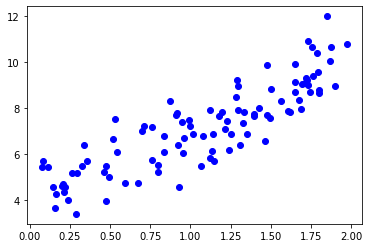

In [5]:
%%time
# importe las librerías necesarias 
import numpy as np 
from numpy import random
import matplotlib.pyplot as plt 


np.random.seed(513)

# cree los datos artificiales 

X = 2*np.random.rand(100,1)
X_b = np.c_[np.ones((100,1)), X]
y = 4 + 3*X + np.random.randn(100,1)

fig, ax = plt.subplots()
ax.plot(X, y, 'bo')

# establecer el rectángulo de visualización
a_,b_ = np.min(X) - 0.1, np.max(X) + 0.1
c_,d_ = 0,12


eta = 0.1      # tasa de aprendizaje pequeña
n_iterations = 1000   # establezca un número de iteraciones
m = 100 # número de instancias 
theta = np.random.randn(2,1) # random initialization



for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    #b, m = theta[0][0], theta[1][0]  
    #ax = plt.gca()
    #ax.plot([a_, b_], [a_*m + b, b_*m+b], 'r-')
    #ax.axis([a_, b_, c_, d_])
    #plt.grid(alpha = 0.3)
    #plt.pause(0.5) 
     
theta     


A la izquierda, la tasa de aprendizaje es demasiado baja: el algoritmo finalmente llegará a la solución, pero llevará mucho tiempo. 

En el medio, la tasa de aprendizaje parece bastante buena: en solo unas pocas iteraciones, ya ha convergido a la solución.

A la derecha, la tasa de aprendizaje es demasiado alta: el algoritmo diverge, salta por todos lados y, de hecho, se aleja más y más de la solución en cada paso.

Para encontrar una buena tasa de aprendizaje, puede utilizar la búsqueda en cuadrícula (consulte el Capítulo 2).

Sin embargo, es posible que desee limitar el número de iteraciones para que la búsqueda en cuadrícula pueda eliminar los modelos que tardan demasiado en converger.

Quizás se pregunte cómo establecer el número de iteraciones.

Si es demasiado bajo, aún estará lejos de la solución óptima cuando el algoritmo se detenga; pero si es demasiado alto, perderá tiempo mientras los parámetros del modelo ya no cambian.

Una solución simple es establecer una gran cantidad de iteraciones pero interrumpir el algoritmo cuando el vector de gradiente se vuelve pequeño, es decir, cuando su norma se vuelve más pequeña que un número pequeño $\epsilon$ (llamado tolerancia), porque esto sucede cuando Gradient Descent ha (casi) alcanzado el mínimo.

## Tasa de convergencia

Cuando la función de costo es convexa y su pendiente no cambia abruptamente (como es el caso de la función de costo MSE), el descenso de gradiente por lotes con una tasa de aprendizaje fija eventualmente convergerá a la solución óptima, pero es posible que tenga que esperar un poco: puede tomar $O(1/\epsilon)$ iteraciones para alcanzar el óptimo dentro de un rango de $\epsilon$, dependiendo de la forma de la función de costo.

Si divide la tolerancia por 10 para tener una solución más precisa, es posible que el algoritmo deba ejecutarse unas 10 veces más.

## Stochastic Gradient Descent

El principal problema con Batch Gradient Descent es el hecho de que **utiliza todo el conjunto de entrenamiento para calcular los gradientes en cada paso,** 
* lo que lo hace muy lento cuando el conjunto de entrenamiento es grande.

En el extremo opuesto, Stochastic Gradient Descent elige una instancia aleatoria en el conjunto de entrenamiento en cada paso y calcula los gradientes basándose únicamente en esa única instancia.

Obviamente, trabajar en una sola instancia a la vez hace que el algoritmo sea mucho más rápido porque tiene muy pocos datos para manipular en cada iteración.

También hace posible entrenar en grandes conjuntos de entrenamiento, ya que solo una instancia necesita estar en la memoria en cada iteración (Stochastic GD puede implementarse como un algoritmo fuera del núcleo; consulte el Capítulo 1).

Por otro lado, debido a su naturaleza estocástica (es decir, aleatoria), este algoritmo es mucho menos regular que el descenso de gradiente por lotes: 
* en lugar de disminuir suavemente hasta llegar al mínimo, la función de costo rebotará hacia arriba y hacia abajo, disminuyendo solo en promedio.

Con el tiempo, terminará muy cerca del mínimo, pero una vez que llegue allí, continuará rebotando, sin asentarse nunca (vea la Figura 4-9).

Entonces, una vez que el algoritmo se detiene, los valores finales de los parámetros son buenos, pero no óptimos.

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_9.png?raw=true'> 

Cuando la función de costo es muy irregular (como en la Figura 4-6), esto puede ayudar al algoritmo a saltar fuera de los mínimos locales, por lo que Stochastic Gradient Descent tiene más posibilidades de encontrar el mínimo global que Batch Gradient Descent.

Por lo tanto, la aleatoriedad es buena para escapar de los óptimos locales, pero mala porque significa que el algoritmo nunca puede establecerse en el mínimo.

Una solución a este dilema es reducir gradualmente la tasa de aprendizaje.

Los pasos comienzan grandes (lo que ayuda a progresar rápidamente y escapar de los mínimos locales), luego se vuelven cada vez más pequeños, lo que permite que el algoritmo se asiente en el mínimo global.

Este proceso es similar al recocido simulado, un algoritmo inspirado en el proceso metalúrgico del recocido, donde el metal fundido se enfría lentamente.

La función que determina la tasa de aprendizaje en cada iteración se denomina programa de aprendizaje. 

Si la tasa de aprendizaje se reduce demasiado rápido, es posible que se quede atascado en un mínimo local o incluso quede congelado a la mitad del mínimo.

Si la tasa de aprendizaje se reduce demasiado lentamente, puede saltar alrededor del mínimo durante mucho tiempo y terminar con una solución subóptima si detiene el entrenamiento demasiado pronto.

Este código implementa Stochastic Gradient Descent utilizando un programa de aprendizaje simple:

In [14]:
%%time 
np.random.seed(513)
m = 100 # número de instancias 
n_epochs = 50 # número de epocas 
t0, t1 = 5, 50 # learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1)
theta = np.random.randn(2,1) # random initialization
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
        
theta         

CPU times: total: 109 ms
Wall time: 91.8 ms


array([[4.03987186],
       [2.90644793]])

Por convención iteramos por rondas de iteraciones; cada ronda se llama una época.

Mientras que el código Batch Gradient Descent iteró 1000 veces a través de todo el conjunto de entrenamiento, este código pasa por el conjunto de entrenamiento solo 50 veces y llega a una solución bastante buena:

In [ ]:
theta

La figura 4-10 muestra los primeros 20 pasos del entrenamiento (observe cuán irregulares son los pasos).

figure 4.10

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_10.png?raw=true'>

Tenga en cuenta que dado que las instancias se eligen al azar, algunas instancias pueden elegirse varias veces por época, mientras que otras pueden no elegirse en absoluto.

Si quiere estar seguro de que el algoritmo pasa por cada instancia en cada época, otro enfoque es barajar el conjunto de entrenamiento (asegurándose de barajar las características de entrada y las etiquetas juntas), luego revisarlo instancia por instancia, luego barajarlo de nuevo, y así sucesivamente.

Sin embargo, este enfoque generalmente converge más lentamente.

## Advertencia

Cuando se usa Stochastic Gradient Descent, las instancias de entrenamiento deben ser independientes e idénticamente distribuidas (IID) para garantizar que los parámetros se acerquen al óptimo global, en promedio.

Una forma sencilla de garantizar esto es barajar las instancias durante el entrenamiento (por ejemplo, elegir cada instancia al azar o barajar el conjunto de entrenamiento al comienzo de cada época).

Si no mezcla las instancias, por ejemplo, si las instancias están ordenadas por etiqueta, entonces SGD comenzará optimizando para una etiqueta, luego la siguiente, y así sucesivamente, y no se establecerá cerca del mínimo global.

Para realizar una regresión lineal usando Stochastic GD con Scikit-Learn, puede usar la clase `SGDRegressor`, que por defecto optimiza la función de costo del error cuadrático.

## Stochastic gradient descent wit sklearn

El siguiente código se ejecuta durante un máximo de 1000 épocas o hasta que la pérdida cae menos de 0,001 durante una época (`max_iter=1000, tol=1e-3`).

Comienza con una tasa de aprendizaje de 0,1 (`eta0=0,1`), utilizando el programa de aprendizaje predeterminado (diferente al anterior).

Por último, no utiliza ninguna regularización (`penalty=None`; más detalles sobre esto en breve):

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

Una vez más, encuentra una solución bastante cercana a la devuelta por la Ecuación Normal:

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

# Mini-batch Gradient Descent

El último algoritmo de descenso de gradiente que veremos se llama descenso de gradiente de mini lotes.

Es fácil de entender una vez que conoce Batch y Stochastic Gradient Descent: en cada paso, en lugar de calcular los gradientes basados en el conjunto de entrenamiento completo (como en Batch GD) o en una sola instancia (como en Stochastic GD), Mini- batch GD calcula los gradientes en pequeños conjuntos aleatorios de instancias llamados mini lotes.

La principal ventaja de Mini-batch GD sobre Stochastic GD es que puede obtener un aumento de rendimiento de la optimización de hardware de las operaciones matriciales, especialmente cuando se usan GPU.

El progreso del algoritmo en el espacio de parámetros es menos errático que con Stochastic GD, especialmente con mini lotes bastante grandes.

Como resultado, Mini-batch GD terminará caminando un poco más cerca del mínimo que Stochastic GD, pero puede ser más difícil para escapar de los mínimos locales (en el caso de problemas que sufren de mínimos locales, a diferencia de la regresión lineal). ).

La figura 4-11 muestra las rutas tomadas por los tres algoritmos de descenso de gradiente en el espacio de parámetros durante el entrenamiento.

Todos terminan cerca del mínimo, pero el camino de Batch GD en realidad se detiene en el mínimo, mientras que Stochastic GD y Mini-batch GD continúan caminando.

Sin embargo, no olvide que Batch GD toma mucho tiempo para dar cada paso, y Stochastic GD y Mini-batch GD también alcanzarían el mínimo si usara un buen programa de aprendizaje.

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_11.png?raw=true'>

Comparemos los algoritmos que hemos discutido hasta ahora para la regresión lineal (recuerde que m es el número de instancias de entrenamiento y n es el número de funciones); consulte la Tabla 4-1.

tabla 4.1
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/tabla_4_1.png?raw=true'>

# NOTA  

Casi no hay diferencia después del entrenamiento: todos estos algoritmos terminan con modelos muy similares y hacen predicciones exactamente de la misma manera.

# Polynomial Regression

¿Qué sucede si sus datos son más complejos que una línea recta? Sorprendentemente, puede usar un modelo lineal para ajustar datos no lineales.

Una forma sencilla de hacer esto es agregar potencias de cada atributo como atributos nuevos y luego entrenar un modelo lineal en este conjunto ampliado de atributos.

Esta técnica se llama regresión polinomial.

Veamos un ejemplo.

Primero, generemos algunos datos no lineales, basados en una ecuación cuadrática simple (más algo de ruido; vea la Figura 4-12):

In [ ]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

figura 4.12  

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_12.png?raw=true'>

Claramente, una línea recta nunca ajustará correctamente estos datos.

Entonces, usemos la clase `PolynomialFeatures` de Scikit-Learn para transformar nuestros datos de entrenamiento, agregando el cuadrado (polinomio de segundo grado) de cada función en el conjunto de entrenamiento como una nueva función (en este caso, solo hay una función):

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

In [ ]:
X_poly[0]


`X_poly` ahora contiene el atributo original de `X` más el cuadrado de este atributo.

Ahora puede ajustar un modelo de 'Regresión lineal' a estos datos de entrenamiento extendidos (Figura 4-13):

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_


figura 4.13
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_13.png?raw=true'>

No está mal: el modelo estima $\hat{y} = 0,56x_{1}^{2} + 0,93x_{1} + 1,78$ cuando en realidad la función original era $y = 0,5x_{1} 2 + 1,0x_ {1} + 2,0 + $ Ruido gaussiano.

Tenga en cuenta que cuando hay varias funciones, la regresión polinómica es capaz de encontrar relaciones entre las funciones (que es algo que un modelo de regresión lineal simple no puede hacer).

Esto es posible gracias al hecho de que `PolynomialFeatures` también agrega todas las combinaciones de atributos hasta el grado dado.

Por ejemplo, si hubiera dos funciones $a$ y $b$, `PolynomialFeatures` con `degree=3` no solo agregaría las funciones $a^{2}$, $a^{3}$, $b^ {2}$ y $b^{3}$, pero también las combinaciones $ab, a^{2}b$ y $ab^{2}$.

## Advertencia

`PolynomialFeatures(degree=d)` transforma una matriz que contiene $n$ características en una matriz que contiene $\frac{(n + d)!}{d! n!}$ características, donde $n!$ es el factorial de $n$, igual a $1 \times 2 \times 3 \times \cdots \times n$.

¡Cuidado con la explosión combinatoria del número de funciones!

# Learning Curves

Si realiza una regresión polinomial de alto grado, es probable que ajuste los datos de entrenamiento mucho mejor que con una regresión lineal simple.

Por ejemplo, la figura 4-14 aplica un modelo polinomial de 300 grados a los datos de entrenamiento anteriores y compara el resultado con un modelo lineal puro y un modelo cuadrático (polinomio de segundo grado).

Observe cómo el modelo polinomial de 300 grados se mueve para acercarse lo más posible a las instancias de entrenamiento.

figura 4.14
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_14.png?raw=true'>

Este modelo de regresión polinomial de alto grado sobreajusta severamente los datos de entrenamiento, mientras que el modelo lineal no los ajusta.

El modelo que generalizará mejor en este caso es el modelo cuadrático, lo cual tiene sentido porque los datos se generaron usando un modelo cuadrático.

Pero, en general, no sabrá qué función generó los datos, entonces, ¿cómo puede decidir qué tan complejo debe ser su modelo? ¿Cómo puede saber si su modelo está sobreajustando o no ajustando los datos?

En el Capítulo 2, utilizó la validación cruzada para obtener una estimación del rendimiento de generalización de un modelo.

If a model performs well on the training data but generalizes poorly according to the cross-validation metrics, then your model is overfitting. 

If it performs poorly on both, then it is underfitting. 

This is one way to tell when a model is too simple or too complex.

Another way to tell is to look at the learning curves: these are plots of the model’s performance on the training set and the validation set as a function of the training set size (or the training iteration). 

To generate the plots, train the model several times on different sized subsets of the training set. 

The following code defines a function that, given some training data, plots the learning curves of a model:

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
        plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
        plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

Let’s look at the learning curves of the plain Linear Regression model (a straight
line; see Figure 4-15):

figure 5.15
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_15.png?raw=true'>

In [ ]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
Figure

This model that’s underfitting deserves a bit of explanation. 

Primero, veamos el rendimiento de los datos de entrenamiento: cuando solo hay una o dos instancias en el conjunto de entrenamiento, el modelo puede ajustarlas perfectamente, razón por la cual la curva comienza en cero.

Pero a medida que se agregan nuevas instancias al conjunto de entrenamiento, se vuelve imposible que el modelo se ajuste perfectamente a los datos de entrenamiento, tanto porque los datos son ruidosos como porque no son lineales en absoluto.

Por lo tanto, el error en los datos de entrenamiento aumenta hasta que llega a una meseta, momento en el que agregar nuevas instancias al conjunto de entrenamiento no hace que el error promedio sea mucho mejor o peor.

Now let’s look at the performance of the model on the validation data. 

Cuando el modelo se entrena en muy pocas instancias de entrenamiento, es incapaz de generalizar correctamente, por lo que el error de validación es inicialmente bastante grande.

Then, as the model is shown more training examples, it learns, and thus the validation error slowly goes down. 

However, once again a straight line cannot do a good job modeling the data, so the error ends up at a plateau, very close to the other curve.

These learning curves are typical of a model that’s underfitting. 

Both curves have reached a plateau; they are close and fairly high.

# Sugerencia

Si su modelo no se ajusta bien a los datos de entrenamiento, agregar más ejemplos de entrenamiento no ayudará.

You need to use a more complex model or come up with better features.

Now let’s look at the learning curves of a 10th-degree polynomial model on the same data (Figure 4-16):

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_16.png?raw=true'>

In [ ]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
("lin_reg", LinearRegression()),
])
plot_learning_curves(polynomial_regression, X, y)

Estas curvas de aprendizaje se parecen un poco a las anteriores, pero hay dos diferencias muy importantes:
El error en los datos de entrenamiento es mucho menor que con el modelo de regresión lineal.

Hay un espacio entre las curvas.

Esto significa que el modelo funciona significativamente mejor con los datos de entrenamiento que con los datos de validación, que es el sello distintivo de un modelo de sobreajuste.

If you used a much larger training set, however, the two curves would continue to get closer.

# Sugerencia

Una forma de mejorar un modelo sobreajustado es alimentarlo con más datos de entrenamiento hasta que el error de validación alcance el error de entrenamiento.

## LA COMPENSACIÓN DE SESGO/VARIANZA

Un resultado teórico importante de la estadística y el aprendizaje automático es el hecho de que el error de generalización de un modelo se puede expresar como la suma de tres errores muy diferentes:

## Prejuicio o parcialidad (bias)

Esta parte del error de generalización se debe a suposiciones incorrectas, como suponer que los datos son lineales cuando en realidad son cuadráticos.

Es más probable que un modelo de alto sesgo se ajuste por debajo de los datos de entrenamiento.

## Variance

Esta parte se debe a la excesiva sensibilidad del modelo a pequeñas variaciones en los datos de entrenamiento.

A model with many degrees of freedom (such as a high-degree polynomial model) is likely to have high variance and thus
overfit the training data.

## Irreducible error

This part is due to the noisiness of the data itself. 

The only way to reduce this part of the error is to clean up the data (e.g., fix the data sources, such as broken sensors, or detect and remove outliers).

Increasing a model’s complexity will typically increase its variance and reduce its bias. 

Conversely, reducing a model’s complexity increases its bias and reduces its variance. This is why it is called a trade-off.

# Regularized Linear Models

As we saw in Chapters 1 and 2, a good way to reduce overfitting is to regularize the model (i.e., to constrain it): the fewer degrees of freedom it has, the harder it will be for it to overfit the data. 

A simple way to regularize a polynomial model is to reduce the number of polynomial degrees.

Para un modelo lineal, la regularización generalmente se logra restringiendo los pesos del modelo.

Ahora veremos Ridge Regression, Lasso Regression y Elastic Net, que implementan tres formas diferentes de restringir los pesos.

# Ridge Regression

La regresión de cresta (también llamada regularización de Tikhonov) es una versión regularizada de la regresión lineal: se agrega un término de regularización igual a $ \alpha \sum_{i = 1}^{n} \theta_{i}^{2} $ a la función de costo. 

Esto obliga al algoritmo de aprendizaje no solo a ajustar los datos, sino también a mantener los pesos del modelo lo más pequeños posible.

Note that the regularization term should only be added to the cost function during training. 

Once the model is
trained, you want to use the unregularized performance measure to evaluate the
model’s performance.

# NOTE

Es bastante común que la función de costo utilizada durante el entrenamiento sea diferente de la medida de desempeño utilizada para la prueba.

Además de la regularización, otra razón por la que pueden ser diferentes es que una buena función de costo de capacitación debe tener derivados fáciles de optimizar, mientras que la medida de rendimiento utilizada para la prueba debe estar lo más cerca posible del objetivo final.

Por ejemplo, los clasificadores a menudo se entrenan usando una función de costo como la pérdida de registros (discutida en un momento) pero se evalúan usando precisión/recuperación.

El hiperparámetro $\alpha$ controla cuánto desea regularizar el modelo.

If $\alpha = 0$, then Ridge Regression is just Linear Regression. 

If $\alpha$ is very large, then all weights end up very close to zero and the result is a flat line going through the data’s mean. 

Equation 4-8 presents the Ridge Regression cost function.

Equation 4-8. Ridge Regression cost function  

$$ J(\theta) = MSE(\theta) + α 12 \sigma n i=1 θi 2 $$

Note that the bias term θ is not regularized (the sum starts at i = 1, not 0). 

If we define w as the vector of feature weights ($θ$ to $θ$ ), then the regularization term is equal to $½(∥ w ∥ $) , where $∥ w ∥$ represents the $ℓ$ norm of the weight vector. 

For Gradient Descent, just add αw to the MSE gradient vector (Equation 4-6).

# ADVERTENCIA

Es importante escalar los datos (p. ej., usando un `StandardScaler`) antes de realizar la regresión de cresta, ya que es sensible a la escala de las entidades de entrada.

Esto es cierto para la mayoría de los modelos regularizados.

La Figura 4-17 muestra varios modelos de Ridge entrenados en algunos datos lineales usando diferentes valores de $\alpha$.

A la izquierda, se utilizan modelos Ridge sencillos, lo que lleva a predicciones lineales.

A la derecha, los datos primero se expanden usando `PolynomialFeatures(degree=10)`, luego se escalan usando un `StandardScaler`, y finalmente los modelos Ridge se aplican a las características resultantes: esto es Polynomial Regression with Ridge regularization.

Observe cómo el aumento de $\alpha$ conduce a predicciones más planas (es decir, menos extremas, más razonables), lo que reduce la varianza del modelo pero aumenta su sesgo.

figura 4.17
<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_17.png?raw=true'>

Al igual que con la regresión lineal, podemos realizar la regresión de cresta calculando una ecuación de forma cerrada o realizando un descenso de gradiente.

Los pros y los contras son los mismos. 

La ecuación 4-9 muestra la solución de forma cerrada, donde $A$ es la matriz identidad $(n + 1) \times (n + 1)$, excepto con $\theta$ en la celda superior izquierda, correspondiente a el término de sesgo.

Equation 4-9. Ridge Regression closed-form solution

$$ \theta = \left(X^{T}X + \alpha A \right)^{-1} X^{T} y $$

Here is how to perform Ridge Regression with Scikit-Learn using a closed-form solution (a variant of Equation 4-9 that uses a matrix factorization technique by André-Louis Cholesky):

In [ ]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

And using Stochastic Gradient Descent:

In [ ]:
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

The penalty hyperparameter sets the type of regularization term to use.

Specifying "l2" indicates that you want SGD to add a regularization term to the cost function equal to half the square of the ℓ norm of the weight vector: this is simply Ridge Regression.

## Lasso Regression

La reducción absoluta mínima y la regresión del operador de selección (generalmente llamada regresión de lazo) es otra versión regularizada de la regresión lineal: al igual que la regresión de cresta, agrega un término de regularización a la función de costo, pero usa la norma ℓ del vector de peso en lugar de la mitad el cuadrado de la norma ℓ (ver Ecuación 4-10).

Equation 4-10. Lasso Regression cost function  

$$ J(\theta) = MSE(\theta) + \alpha \sum_{i = 1}^{n} |θ_{i}| $$

Figure 4-18 shows the same thing as Figure 4-17 but replaces Ridge models with Lasso models and uses smaller $\alpha$ values.

figura 4.18  

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_18.png?raw=true'>

An important characteristic of Lasso Regression is that it tends to eliminate the weights of the least important features (i.e., set them to zero). 

For example, the
dashed line in the righthand plot in Figure 4-18 (with α = 10 ) looks quadratic,
almost linear: all the weights for the high-degree polynomial features are equal
to zero. In other words, Lasso Regression automatically performs feature
selection and outputs a sparse model (i.e., with few nonzero feature weights).
You can get a sense of why this is the case by looking at Figure 4-19: the axes
represent two model parameters, and the background contours represent different
loss functions. In the top-left plot, the contours represent the ℓ loss (|θ | + |θ |),
which drops linearly as you get closer to any axis. For example, if you initialize
the model parameters to θ = 2 and θ = 0.5, running Gradient Descent will
decrement both parameters equally (as represented by the dashed yellow line);
therefore θ will reach 0 first (since it was closer to 0 to begin with). After that,
Gradient Descent will roll down the gutter until it reaches θ = 0 (with a bit of
bouncing around, since the gradients of ℓ never get close to 0: they are either –1
or 1 for each parameter). In the top-right plot, the contours represent Lasso’s cost
function (i.e., an MSE cost function plus an ℓ loss). The small white circles
show the path that Gradient Descent takes to optimize some model parameters
that were initialized around θ = 0.25 and θ = –1: notice once again how the
path quickly reaches θ = 0, then rolls down the gutter and ends up bouncing
around the global optimum (represented by the red square). If we increased α,
the global optimum would move left along the dashed yellow line, while if we decreased α, the global optimum would move right (in this example, the optimal
parameters for the unregularized MSE are θ = 2 and θ = 0.5).

<img src = 'https://github.com/marco-canas/didactica_ciencia_datos/blob/main/referentes/geron/part_1/c_4/fig_4_19.png?raw=true'>

The two bottom plots show the same thing but with an ℓ penalty instead. In the
bottom-left plot, you can see that the ℓ loss decreases with the distance to the
origin, so Gradient Descent just takes a straight path toward that point. In the
bottom-right plot, the contours represent Ridge Regression’s cost function (i.e.,
an MSE cost function plus an ℓ loss). There are two main differences with
Lasso. First, the gradients get smaller as the parameters approach the global
optimum, so Gradient Descent naturally slows down, which helps convergence
(as there is no bouncing around). Second, the optimal parameters (represented by
the red square) get closer and closer to the origin when you increase α, but they
never get eliminated entirely.

## Referentes   

* Cuadernos Jupyter de Geron en GitHub de la tercera edición de manos a la obra al machine learning con sklearn: https://github.com/ageron/handson-ml3

* Compute least-squares solution to equation Ax = b: https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html